In [1]:
import jax 
import jax.numpy as jnp

from probjax.core.jaxpr_propagation.graph import JaxprGraph, DirectedVariableGraph

In [26]:

from probjax.distributions import Normal
from probjax.core.custom_primitives.random_variable import rv, rv_p

p = rv(Normal(0.,1.), "X")

def f(theta):
    x0 = p(jax.random.PRNGKey(0))
    xs = []
    for i in range(1):
        x0 = x0 + x0* theta
        xs.append(x0)
    return xs


def f(x):
    return jax.nn.leaky_relu(x)

def f(x, y):
    return x + y, x - y



jaxpr = jax.make_jaxpr(f)(jnp.ones(2), jnp.ones(2))

In [27]:
jaxpr

{ lambda ; a:f32[2] b:f32[2]. let
    c:f32[2] = add a b
    d:f32[2] = sub a b
  in (c, d) }

In [28]:
g = JaxprGraph(jaxpr.jaxpr)


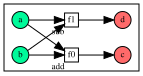

In [ ]:
# Invertible linear system
# c = a + b
# d = a -b 

# a = c - b
# b = (c - d)/2

# a = (c + d)/2
# b = (c - d)/2

In [45]:
f(0.5,0.5)

(1.0, 0.0)

In [46]:
def greedy_solve_linear_system(A, b):
    n = A.shape[0]
    x = jnp.zeros(n)
    for i in range(n):
        x = x[i] + (x.at[i].set(b[i] - jnp.dot(A[i], x))/jnp.sum(A[i]**2)) * A[i]
    return x


greedy_solve_linear_system(jnp.array([[1., 1.], [1., -1.]]), jnp.array([1., 0.]))

Array([0.25, 0.25], dtype=float32)

In [44]:
A @ jnp.array([.5, .5])

Array([1., 0.], dtype=float32)

In [42]:
jnp.linalg.solve(jnp.array([[1., 1.], [1., -1.]]), jnp.array([2., 0.]))

Array([1., 1.], dtype=float32)